# Persona Ratings Analysis Pipeline

This notebook is the notebook-format version of `Stimulus_Builder/analyze_ratings.py`.
It keeps the same functionality, but in a step-by-step runnable and presentation-friendly format.


## Assumptions Before Running Code

1. **Assumed input schema**: one row per rating event with persona metadata, stimulus metadata, variant/condition fields, rating outcome (`q1`, `q2`, or `rating`), and optional `motivation` text.
2. **Matching logic used**: `is_matched = 1` iff the message target trait equals persona trait (`E_PLUS -> E_HIGH`, `O_PLUS -> O_HIGH`), otherwise `0`. `GENERIC` is coded as unmatched (`0`) because it is not trait-targeted.
3. **Main regression formula**: `rating ~ is_matched + C(persona_trait) + is_matched:C(persona_trait)` (+ controls such as `product_id`, `paraphrase_id`, `model` when available).


## 1. Imports


In [2]:
import json
import re
from collections import Counter
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf


## 2. User Configuration / File Paths / Column Mapping


In [3]:
# ---------- User-editable paths ----------
BASE_DIR = Path.cwd()


def resolve_stimulus_builder_dir(base_dir: Path) -> Path:
    candidates = [
        base_dir,
        base_dir / "Stimulus_Builder",
        base_dir.parent / "Stimulus_Builder",
    ]
    for c in candidates:
        if (c / "persona_ratings_out").exists():
            return c
    # Fallback keeps behavior predictable even if folders are not created yet.
    return base_dir / "Stimulus_Builder"


STIMULUS_BUILDER_DIR = resolve_stimulus_builder_dir(BASE_DIR)
CANONICAL_OUT_DIR = STIMULUS_BUILDER_DIR / "stimuli_out_analysed" / "ratings_analysis_pipeline"
NOTEBOOK_OUT_DIR = STIMULUS_BUILDER_DIR / "stimuli_out_analysed" / "ratings_analysis_pipeline_notebook"
DEFAULT_INPUT_PATH = STIMULUS_BUILDER_DIR / "persona_ratings_out"
DEFAULT_OUT_DIR = NOTEBOOK_OUT_DIR
FINAL_ROWLEVEL_CSV = CANONICAL_OUT_DIR / "analysis_rows_standardized.csv"

INPUT_PATH = DEFAULT_INPUT_PATH
OUT_DIR = DEFAULT_OUT_DIR
MIRROR_OUT_DIRS = [OUT_DIR, CANONICAL_OUT_DIR]

print(f"Current working directory: {BASE_DIR}")
print(f"Resolved Stimulus_Builder directory: {STIMULUS_BUILDER_DIR}")
print(f"Canonical analysis dir: {CANONICAL_OUT_DIR}")
print(f"Notebook analysis dir: {OUT_DIR}")
print(f"Final row-level CSV source: {FINAL_ROWLEVEL_CSV}")

# ---------- Column mapping section (edit if your dataset names differ) ----------
COLUMN_CANDIDATES: dict[str, list[str]] = {
    "persona_id": ["persona_id", "participant.persona_id", "participant_persona_id"],
    "participant_type": [
        "participant_type",
        "participant.participant_type",
        "participant_participant_type",
    ],
    "stimulus_id": ["stimulus_id", "output_id", "trial.output_id", "trial_output_id"],
    "condition_id": ["condition_id", "trial.condition_id", "trial_condition_id"],
    "product_id": ["product_id", "trial.product_id", "trial_product_id"],
    "product_name": ["product_name", "trial.product_name", "trial_product_name"],
    "variant": ["variant", "stimulus_variant", "trial.stimulus_variant", "trial_stimulus_variant"],
    "condition_label": ["condition_label", "trial.condition_label", "trial_condition_label"],
    "paraphrase_id": ["paraphrase_id", "trial.paraphrase_id", "trial_paraphrase_id"],
    "model": ["model"],
    "motivation": ["motivation", "rating.motivation", "rating_motivation"],
    "q1": ["q1", "effectiveness_rating_q1", "rating.effectiveness_rating_q1", "rating_effectiveness_rating_q1"],
    "q2": ["q2", "effectiveness_rating_q2", "rating.effectiveness_rating_q2", "rating_effectiveness_rating_q2"],
    "rating": ["rating", "combined", "mean_rating"],
}

PERSONA_TO_TRAIT = {
    "TYPE_E_HIGH": "E_HIGH",
    "TYPE_O_HIGH": "O_HIGH",
}

VARIANT_TO_TARGET_TRAIT = {
    "E_PLUS": "E_HIGH",
    "O_PLUS": "O_HIGH",
    "GENERIC": "GENERIC",
}

VARIANT_TO_FEATURE_FAMILY = {
    "E_PLUS": "social_arousal",
    "O_PLUS": "abstract_creative",
    "GENERIC": "structured_concrete",
}

VARIANT_TO_FEATURE_TAGS = {
    "E_PLUS": "social|arousal",
    "O_PLUS": "abstract|creative",
    "GENERIC": "structured|concrete",
}

REQUIRED_CANONICAL_COLUMNS = [
    "persona_id",
    "persona_trait",
    "stimulus_id",
    "product_id",
    "variant",
    "rating",
]

STOPWORDS = {
    "a", "an", "and", "are", "as", "at", "be", "by", "for", "from", "has", "have",
    "i", "in", "is", "it", "its", "my", "of", "on", "or", "that", "the", "this", "to",
    "was", "were", "with",
}

print(f"INPUT_PATH: {INPUT_PATH}")
print(f"OUT_DIR: {OUT_DIR}")


Current working directory: c:\Users\alect\OneDrive\Masters\031_Modeling_Communication_and_Abstraction_Part_I\Final project\AI_personality_persuasion-1\Stimulus_Builder
Resolved Stimulus_Builder directory: c:\Users\alect\OneDrive\Masters\031_Modeling_Communication_and_Abstraction_Part_I\Final project\AI_personality_persuasion-1\Stimulus_Builder
Canonical analysis dir: c:\Users\alect\OneDrive\Masters\031_Modeling_Communication_and_Abstraction_Part_I\Final project\AI_personality_persuasion-1\Stimulus_Builder\stimuli_out_analysed\ratings_analysis_pipeline
Notebook analysis dir: c:\Users\alect\OneDrive\Masters\031_Modeling_Communication_and_Abstraction_Part_I\Final project\AI_personality_persuasion-1\Stimulus_Builder\stimuli_out_analysed\ratings_analysis_pipeline_notebook
Final row-level CSV source: c:\Users\alect\OneDrive\Masters\031_Modeling_Communication_and_Abstraction_Part_I\Final project\AI_personality_persuasion-1\Stimulus_Builder\stimuli_out_analysed\ratings_analysis_pipeline\analys

## 3. Load Data


**What This Cell Does**

- Loads ratings from either a folder of JSON rating files or a table-style input (`.csv`, `.json`, `.jsonl`).
- Keeps only successful rating records (`status == "ok"`) for JSON pipeline outputs.
- Standardizes core raw fields into a row-per-rating structure before analysis.

**How To Read The Output**

- The `Loaded X successful rating rows...` line shows the usable sample size entering analysis.
- The preview (`df_raw.head()`) helps confirm that each row is one persona rating one message.


In [4]:
def _first_existing(colnames: set[str], candidates: list[str]) -> str | None:
    for c in candidates:
        if c in colnames:
            return c
    return None


def _parse_raw_rating_json(path: Path) -> dict[str, Any] | None:
    payload = json.loads(path.read_text(encoding="utf-8"))
    if payload.get("status") != "ok":
        return None

    participant = payload.get("participant", {})
    trial = payload.get("trial", {})
    rating = payload.get("rating", {})

    q1 = rating.get("effectiveness_rating_q1")
    q2 = rating.get("effectiveness_rating_q2")

    row = {
        "source_file": path.name,
        "status": payload.get("status"),
        "timestamp_utc": payload.get("timestamp_utc"),
        "model": payload.get("model"),
        "model_temperature": payload.get("model_temperature"),
        "persona_id": participant.get("persona_id"),
        "participant_type": participant.get("participant_type"),
        "respondent_seed": participant.get("respondent_seed"),
        "trial_index": trial.get("trial_index"),
        "condition_label": trial.get("condition_label"),
        "variant": trial.get("stimulus_variant"),
        "stimulus_id": trial.get("output_id") or trial.get("condition_id"),
        "condition_id": trial.get("condition_id"),
        "output_id": trial.get("output_id"),
        "product_id": trial.get("product_id"),
        "product_name": trial.get("product_name"),
        "paraphrase_id": trial.get("paraphrase_id"),
        "full_message": trial.get("full_message"),
        "q1": q1,
        "q2": q2,
        "motivation": rating.get("motivation"),
    }

    if q1 is not None and q2 is not None:
        row["rating"] = (float(q1) + float(q2)) / 2.0
    else:
        row["rating"] = np.nan

    return row


def _normalize_input_path(input_path: Path) -> Path:
    input_path = Path(input_path)

    # Repair common accidental duplication: .../Stimulus_Builder/Stimulus_Builder/...
    parts = list(input_path.parts)
    for i in range(len(parts) - 1):
        if parts[i].lower() == "stimulus_builder" and parts[i + 1].lower() == "stimulus_builder":
            repaired = Path(*parts[: i + 1], *parts[i + 2 :])
            if repaired.exists():
                print(f"[path-fix] Using repaired path: {repaired}")
                return repaired

    # If path is missing, try likely cwd-relative candidates.
    if not input_path.exists() and input_path.name == "persona_ratings_out":
        cwd = Path.cwd()
        candidates = [
            cwd / "persona_ratings_out",
            cwd / "Stimulus_Builder" / "persona_ratings_out",
            cwd.parent / "Stimulus_Builder" / "persona_ratings_out",
        ]
        for c in candidates:
            if c.exists():
                print(f"[path-fix] Using discovered path: {c}")
                return c

    return input_path


def load_input_data(input_path: Path) -> pd.DataFrame:
    input_path = _normalize_input_path(input_path)

    if input_path.is_dir():
        rows: list[dict[str, Any]] = []
        for fp in sorted(input_path.glob("*.json")):
            try:
                parsed = _parse_raw_rating_json(fp)
                if parsed is not None:
                    rows.append(parsed)
            except Exception as exc:
                print(f"[skip] Could not parse {fp.name}: {exc}")

        if not rows:
            raise RuntimeError(f"No valid rating rows found in directory: {input_path}")

        df = pd.DataFrame(rows)
        print(f"Loaded {len(df)} successful rating rows from JSON directory: {input_path}")
        return df

    suffix = input_path.suffix.lower()
    if suffix == ".csv":
        df = pd.read_csv(input_path)
        print(f"Loaded CSV file: {input_path}")
        return df

    if suffix in {".jsonl", ".ndjson"}:
        df = pd.read_json(input_path, lines=True)
        print(f"Loaded JSONL file: {input_path}")
        return df

    if suffix == ".json":
        raw = json.loads(input_path.read_text(encoding="utf-8"))
        if isinstance(raw, list):
            df = pd.json_normalize(raw)
        elif isinstance(raw, dict):
            if {"participant", "trial", "rating"}.issubset(raw.keys()):
                parsed = _parse_raw_rating_json(input_path)
                if parsed is None:
                    raise RuntimeError(f"Single JSON file is not status='ok': {input_path}")
                df = pd.DataFrame([parsed])
            else:
                df = pd.json_normalize(raw)
        else:
            raise RuntimeError(f"Unsupported JSON structure in file: {input_path}")
        print(f"Loaded JSON file: {input_path}")
        return df

    raise RuntimeError(f"Unsupported input type: {input_path}")


df_raw = load_input_data(INPUT_PATH)
df_raw.head()


Loaded 360 successful rating rows from JSON directory: c:\Users\alect\OneDrive\Masters\031_Modeling_Communication_and_Abstraction_Part_I\Final project\AI_personality_persuasion-1\Stimulus_Builder\persona_ratings_out


,source_file,status,timestamp_utc,model,model_temperature,persona_id,participant_type,respondent_seed,trial_index,condition_label,...,condition_id,output_id,product_id,product_name,paraphrase_id,full_message,q1,q2,motivation,rating
0,PER_EHIGH_0001__t01__3371e94acf164ac9.json,ok,2026-03-22T15:35:34Z,mistral-large-3-675b-instruct-2512,NaN,PER_EHIGH_0001,TYPE_E_HIGH,110001,1,TARGETED,...,54b2e74589abdef8,3371e94acf164ac9,P1,Weekend city trip,1,Ready for an adventure-packed weekend getaway?...,7,7,"The ad’s lively, socially engaging tone and hi...",7.0
1,PER_EHIGH_0001__t02__ebcf95a419d7ca17.json,ok,2026-03-22T17:06:24Z,mistral-large-3-675b-instruct-2512,0.2,PER_EHIGH_0001,TYPE_E_HIGH,110001,2,NON_TARGETED,...,461c8ba5b4047818,ebcf95a419d7ca17,P1,Weekend city trip,1,Explore the city from a brand-new perspective....,5,4,"The ad feels thoughtful but lacks the lively, ...",4.5
2,PER_EHIGH_0001__t03__f5d2072131c0d4b3.json,ok,2026-03-22T17:06:25Z,mistral-large-3-675b-instruct-2512,0.2,PER_EHIGH_0001,TYPE_E_HIGH,110001,3,GENERIC,...,119900dc85bd8278,f5d2072131c0d4b3,P1,Weekend city trip,1,Dreaming of a refreshing city escape? Two nigh...,5,4,The ad feels a bit too generic and lacks the l...,4.5
3,PER_EHIGH_0001__t04__f1dd44da64717dd8.json,ok,2026-03-22T17:06:26Z,mistral-large-3-675b-instruct-2512,0.2,PER_EHIGH_0001,TYPE_E_HIGH,110001,4,TARGETED,...,402909928f6a2c01,f1dd44da64717dd8,P4,Language-learning course,1,Ready to dive into a new adventure with friend...,7,6,"The ad’s lively, social energy and confident t...",6.5
4,PER_EHIGH_0001__t05__b582b4a0eebff4a3.json,ok,2026-03-22T17:06:28Z,mistral-large-3-675b-instruct-2512,0.2,PER_EHIGH_0001,TYPE_E_HIGH,110001,5,GENERIC,...,53744078cc1c0f1c,b582b4a0eebff4a3,P4,Language-learning course,1,Discover a new way to enhance your language sk...,4,3,The ad feels too methodical and lacks the ener...,3.5


## 4. Validation Checks


**Why These Checks Matter**

- `Shape` and `Columns` confirm the dataset is what you expect.
- `Missing values` highlights fields that could bias results if many are absent.
- `Duplicated full rows` flags exact duplicates that can inflate precision if not addressed.
- Required-column checks fail early with a clear error when mapping is incomplete.

**Interpretation Tip**

- A few missing optional fields (for example `motivation`) can be acceptable.
- Missingness in key fields (`persona_id`, `variant`, `rating`) is more serious and should be fixed before interpreting inferential results.


In [5]:
def print_validation_overview(df: pd.DataFrame) -> None:
    print("=== Validation: Raw input overview ===")
    print(f"Shape: {df.shape}")
    print("Columns:")
    print(sorted(df.columns.tolist()))

    missing_counts = df.isna().sum().sort_values(ascending=False)
    print()
    print("Missing values (top columns):")
    print(missing_counts.head(15))

    total_dup_rows = int(df.duplicated().sum())
    print()
    print(f"Duplicated full rows: {total_dup_rows}")


def standardize_columns(df_raw: pd.DataFrame) -> pd.DataFrame:
    df = df_raw.copy()
    colset = set(df.columns)

    mapped: dict[str, pd.Series] = {}
    for canonical, candidates in COLUMN_CANDIDATES.items():
        found = _first_existing(colset, candidates)
        if found is not None:
            mapped[canonical] = df[found]

    standardized = pd.DataFrame(mapped)

    if "rating" not in standardized.columns:
        q1_col = mapped.get("q1")
        q2_col = mapped.get("q2")
        if q1_col is not None and q2_col is not None:
            standardized["rating"] = (
                pd.to_numeric(q1_col, errors="coerce") + pd.to_numeric(q2_col, errors="coerce")
            ) / 2.0

    if "stimulus_id" not in standardized.columns and "condition_id" in standardized.columns:
        standardized["stimulus_id"] = standardized["condition_id"]

    return standardized


def infer_persona_trait(row: pd.Series) -> str:
    participant_type = str(row.get("participant_type", "") or "").strip()
    persona_id = str(row.get("persona_id", "") or "").upper()

    if participant_type in PERSONA_TO_TRAIT:
        return PERSONA_TO_TRAIT[participant_type]
    if "EHIGH" in persona_id or "TYPE_E_HIGH" in persona_id:
        return "E_HIGH"
    if "OHIGH" in persona_id or "TYPE_O_HIGH" in persona_id:
        return "O_HIGH"
    return "UNKNOWN"


def fail_if_required_missing(df_std: pd.DataFrame) -> None:
    missing = [c for c in REQUIRED_CANONICAL_COLUMNS if c not in df_std.columns]
    if missing:
        raise ValueError(
            "Missing required analysis columns after mapping: "
            + str(missing)
            + "\nPlease edit COLUMN_CANDIDATES at the top of this notebook so your schema maps correctly."
        )


print_validation_overview(df_raw)

df_std = standardize_columns(df_raw)
if "persona_trait" not in df_std.columns:
    tmp = df_std.copy()
    if "participant_type" not in tmp.columns:
        tmp["participant_type"] = np.nan
    df_std["persona_trait"] = tmp.apply(infer_persona_trait, axis=1)

fail_if_required_missing(df_std)
print()
print("Standardized columns ready.")
print(sorted(df_std.columns.tolist()))


=== Validation: Raw input overview ===
Shape: (360, 22)
Columns:
['condition_id', 'condition_label', 'full_message', 'model', 'model_temperature', 'motivation', 'output_id', 'paraphrase_id', 'participant_type', 'persona_id', 'product_id', 'product_name', 'q1', 'q2', 'rating', 'respondent_seed', 'source_file', 'status', 'stimulus_id', 'timestamp_utc', 'trial_index', 'variant']

Missing values (top columns):
model_temperature    3
source_file          0
status               0
timestamp_utc        0
model                0
persona_id           0
participant_type     0
respondent_seed      0
trial_index          0
condition_label      0
variant              0
stimulus_id          0
condition_id         0
output_id            0
product_id           0
dtype: int64

Duplicated full rows: 0

Standardized columns ready.
['condition_id', 'condition_label', 'model', 'motivation', 'paraphrase_id', 'participant_type', 'persona_id', 'persona_trait', 'product_id', 'product_name', 'q1', 'q2', 'rating',

## 5. Variable Construction


**Constructed Variables (Core To Theory)**

- `persona_trait`: inferred persona type (`E_HIGH` or `O_HIGH`).
- `target_trait`: trait targeted by the message variant (`E_PLUS -> E_HIGH`, `O_PLUS -> O_HIGH`, `GENERIC -> GENERIC`).
- `is_matched`: equals `1` only if the targeted trait equals the persona trait; otherwise `0`.
- `message_feature_family`: transparent tag of the linguistic framing family used for each variant.

**How To Interpret `is_matched`**

- `is_matched = 1`: message-persona alignment (theoretical match condition).
- `is_matched = 0`: mismatch or generic condition.
- This is the key manipulation variable used in both descriptives and regression.


In [6]:
def clean_and_derive_variables(df_std: pd.DataFrame) -> pd.DataFrame:
    df = df_std.copy()

    df["persona_id"] = df["persona_id"].astype(str)
    df["variant"] = df["variant"].astype(str).str.upper().str.strip()
    df["product_id"] = df["product_id"].astype(str)

    if "participant_type" not in df.columns:
        df["participant_type"] = np.nan

    if "condition_label" in df.columns:
        df["condition_label"] = df["condition_label"].astype(str).str.upper().str.strip()

    df["rating"] = pd.to_numeric(df["rating"], errors="coerce")

    df["persona_trait"] = df.apply(infer_persona_trait, axis=1)
    df["target_trait"] = df["variant"].map(VARIANT_TO_TARGET_TRAIT).fillna("UNKNOWN")
    df["message_feature_family"] = df["variant"].map(VARIANT_TO_FEATURE_FAMILY).fillna("unknown")
    df["message_feature_tags"] = df["variant"].map(VARIANT_TO_FEATURE_TAGS).fillna("unknown")

    # Explicit and transparent matching logic:
    # is_matched = 1 only when a trait-targeted variant matches the persona trait.
    # Generic variants are coded 0 because they do not target E or O.
    df["is_matched"] = (
        (df["target_trait"].isin(["E_HIGH", "O_HIGH"]))
        & (df["target_trait"] == df["persona_trait"])
    ).astype(int)

    if "motivation" in df.columns:
        df["motivation"] = df["motivation"].astype(str)

    before = len(df)
    df = df[df["rating"].notna()].copy()
    dropped = before - len(df)
    if dropped > 0:
        print(f"Dropped {dropped} rows with missing/non-numeric rating.")

    return df


df_analysis = clean_and_derive_variables(df_std)

print("=== Validation: Analysis dataset overview ===")
print(f"Shape: {df_analysis.shape}")
print("Columns:")
print(sorted(df_analysis.columns.tolist()))
print()
print("Missing values (top columns):")
print(df_analysis.isna().sum().sort_values(ascending=False).head(15))

key_cols = [c for c in ["persona_id", "stimulus_id", "model"] if c in df_analysis.columns]
if key_cols:
    print(f"Duplicated rows by keys {key_cols}: {int(df_analysis.duplicated(subset=key_cols).sum())}")

df_analysis.head()


=== Validation: Analysis dataset overview ===
Shape: (360, 19)
Columns:
['condition_id', 'condition_label', 'is_matched', 'message_feature_family', 'message_feature_tags', 'model', 'motivation', 'paraphrase_id', 'participant_type', 'persona_id', 'persona_trait', 'product_id', 'product_name', 'q1', 'q2', 'rating', 'stimulus_id', 'target_trait', 'variant']

Missing values (top columns):
persona_id          0
participant_type    0
stimulus_id         0
condition_id        0
product_id          0
product_name        0
variant             0
condition_label     0
paraphrase_id       0
model               0
motivation          0
q1                  0
q2                  0
rating              0
persona_trait       0
dtype: int64
Duplicated rows by keys ['persona_id', 'stimulus_id', 'model']: 0


,persona_id,participant_type,stimulus_id,condition_id,product_id,product_name,variant,condition_label,paraphrase_id,model,motivation,q1,q2,rating,persona_trait,target_trait,message_feature_family,message_feature_tags,is_matched
0,PER_EHIGH_0001,TYPE_E_HIGH,3371e94acf164ac9,54b2e74589abdef8,P1,Weekend city trip,E_PLUS,TARGETED,1,mistral-large-3-675b-instruct-2512,"The ad’s lively, socially engaging tone and hi...",7,7,7.0,E_HIGH,E_HIGH,social_arousal,social|arousal,1
1,PER_EHIGH_0001,TYPE_E_HIGH,ebcf95a419d7ca17,461c8ba5b4047818,P1,Weekend city trip,O_PLUS,NON_TARGETED,1,mistral-large-3-675b-instruct-2512,"The ad feels thoughtful but lacks the lively, ...",5,4,4.5,E_HIGH,O_HIGH,abstract_creative,abstract|creative,0
2,PER_EHIGH_0001,TYPE_E_HIGH,f5d2072131c0d4b3,119900dc85bd8278,P1,Weekend city trip,GENERIC,GENERIC,1,mistral-large-3-675b-instruct-2512,The ad feels a bit too generic and lacks the l...,5,4,4.5,E_HIGH,GENERIC,structured_concrete,structured|concrete,0
3,PER_EHIGH_0001,TYPE_E_HIGH,f1dd44da64717dd8,402909928f6a2c01,P4,Language-learning course,E_PLUS,TARGETED,1,mistral-large-3-675b-instruct-2512,"The ad’s lively, social energy and confident t...",7,6,6.5,E_HIGH,E_HIGH,social_arousal,social|arousal,1
4,PER_EHIGH_0001,TYPE_E_HIGH,b582b4a0eebff4a3,53744078cc1c0f1c,P4,Language-learning course,GENERIC,GENERIC,1,mistral-large-3-675b-instruct-2512,The ad feels too methodical and lacks the ener...,4,3,3.5,E_HIGH,GENERIC,structured_concrete,structured|concrete,0


## 6. Descriptive Statistics


**What These Tables Show**

- Count tables (`n`) describe sample balance across persona traits, variants, products, and matched status.
- Rating tables report `rating_mean` and `rating_sd` by group.

**How To Read Values**

- `rating_mean`: average persuasion rating (higher means more persuasive).
- `rating_sd`: variability within group (higher means less consistency across observations).
- `n`: number of rating events contributing to that estimate.

**Why This Step Comes Before Modeling**

- It checks for obvious imbalance or anomalies before inferential claims.
- It provides baseline effect patterns to compare against regression estimates.


In [7]:
def descriptive_tables(df: pd.DataFrame) -> dict[str, pd.DataFrame]:
    tables: dict[str, pd.DataFrame] = {}

    tables["count_by_persona_trait"] = (
        df.groupby("persona_trait", dropna=False).size().reset_index(name="n").sort_values("persona_trait")
    )

    tables["count_by_variant"] = (
        df.groupby("variant", dropna=False).size().reset_index(name="n").sort_values("variant")
    )

    tables["count_by_product"] = (
        df.groupby("product_id", dropna=False).size().reset_index(name="n").sort_values("product_id")
    )

    tables["count_by_matched"] = (
        df.groupby("is_matched", dropna=False).size().reset_index(name="n").sort_values("is_matched")
    )

    tables["rating_by_persona_trait"] = (
        df.groupby("persona_trait", dropna=False)["rating"]
        .agg(["count", "mean", "std"])
        .reset_index()
        .rename(columns={"count": "n", "mean": "rating_mean", "std": "rating_sd"})
    )

    tables["rating_by_variant"] = (
        df.groupby("variant", dropna=False)["rating"]
        .agg(["count", "mean", "std"])
        .reset_index()
        .rename(columns={"count": "n", "mean": "rating_mean", "std": "rating_sd"})
    )

    tables["rating_by_matched"] = (
        df.groupby("is_matched", dropna=False)["rating"]
        .agg(["count", "mean", "std"])
        .reset_index()
        .rename(columns={"count": "n", "mean": "rating_mean", "std": "rating_sd"})
    )

    tables["rating_by_persona_trait_x_matched"] = (
        df.groupby(["persona_trait", "is_matched"], dropna=False)["rating"]
        .agg(["count", "mean", "std"])
        .reset_index()
        .rename(columns={"count": "n", "mean": "rating_mean", "std": "rating_sd"})
    )

    return tables


def print_descriptive_tables(tables: dict[str, pd.DataFrame]) -> None:
    print("=== Descriptive statistics ===")
    for name, table in tables.items():
        print()
        print(f"{name}:")
        print(table.to_string(index=False))


descriptive = descriptive_tables(df_analysis)
print_descriptive_tables(descriptive)


=== Descriptive statistics ===

count_by_persona_trait:
persona_trait   n
       E_HIGH 180
       O_HIGH 180

count_by_variant:
variant   n
 E_PLUS 120
GENERIC 120
 O_PLUS 120

count_by_product:
product_id  n
        P1 60
        P2 60
        P3 60
        P4 60
        P5 60
        P6 60

count_by_matched:
 is_matched   n
          0 240
          1 120

rating_by_persona_trait:
persona_trait   n  rating_mean  rating_sd
       E_HIGH 180     5.161111   1.175466
       O_HIGH 180     5.530556   1.093613

rating_by_variant:
variant   n  rating_mean  rating_sd
 E_PLUS 120     6.233333   0.434506
GENERIC 120     4.291667   0.771290
 O_PLUS 120     5.512500   1.119841

rating_by_matched:
 is_matched   n  rating_mean  rating_sd
          0 240     4.747917   0.945146
          1 120     6.541667   0.153165

rating_by_persona_trait_x_matched:
persona_trait  is_matched   n  rating_mean  rating_sd
       E_HIGH           0 120     4.445833   0.715365
       E_HIGH           1  60     6.591

## 7. Visualizations


**How To Interpret The Figures**

1. `01_rating_distribution_overall`: shape of all ratings (ceiling/floor effects, skew).
2. `02_mean_rating_by_persona_trait`: whether one persona group rates higher overall.
3. `03_mean_rating_by_matched`: visual estimate of average matched-vs-nonmatched advantage.
4. `04_mean_rating_trait_x_matched`: interaction pattern (does the match advantage differ by persona trait?).
5. `05_mean_rating_trait_x_variant`: descriptive breakdown of the final three message types (`E_PLUS`, `O_PLUS`, `GENERIC`).

Variant-plot interpretation:

- For `E_HIGH`, `E_PLUS` is matched and `O_PLUS` is non-targeted.
- For `O_HIGH`, `O_PLUS` is matched and `E_PLUS` is non-targeted.
- `GENERIC` is the neutral comparison condition.
- This plot helps separate a true personality-match effect from a broad advantage of targeted-style language.

All mean bar charts below use standard error bars (mean +/- SE).


In [8]:
def _summary_with_se(df: pd.DataFrame, group_cols: list[str]) -> pd.DataFrame:
    out = (
        df.groupby(group_cols, dropna=False)["rating"]
        .agg(n="count", mean="mean", sd="std")
        .reset_index()
    )
    out["se"] = out["sd"] / np.sqrt(out["n"])
    out["se"] = out["se"].fillna(0.0)
    return out


def make_plots(df: pd.DataFrame, out_dir: Path) -> list[Path]:
    figures_dir = out_dir / "figures"
    figures_dir.mkdir(parents=True, exist_ok=True)

    plot_paths: list[Path] = []

    # 01: rating distribution overall
    plt.figure(figsize=(8, 5))
    bins = np.arange(0.5, 7.6, 0.5)
    plt.hist(df["rating"].dropna(), bins=bins, edgecolor="black")
    plt.title("Overall Rating Distribution")
    plt.xlabel("Rating")
    plt.ylabel("Count")
    p1 = figures_dir / "01_rating_distribution_overall.png"
    plt.tight_layout()
    plt.savefig(p1, dpi=300)
    plt.close()
    plot_paths.append(p1)

    # 02: mean rating by persona trait with SE bars
    s_trait = _summary_with_se(df, ["persona_trait"]).sort_values("persona_trait")
    x = np.arange(len(s_trait))
    plt.figure(figsize=(8, 5))
    plt.bar(x, s_trait["mean"], yerr=s_trait["se"], capsize=4)
    plt.xticks(x, s_trait["persona_trait"])
    plt.title("Mean Rating by Persona Trait")
    plt.xlabel("Persona Trait")
    plt.ylabel("Mean Rating")
    p2 = figures_dir / "02_mean_rating_by_persona_trait.png"
    plt.tight_layout()
    plt.savefig(p2, dpi=300)
    plt.close()
    plot_paths.append(p2)

    # 03: mean rating by matched vs nonmatched with SE bars
    tmp = df.copy()
    tmp["match_label"] = np.where(tmp["is_matched"] == 1, "Matched", "Non-matched")
    s_match = _summary_with_se(tmp, ["match_label"])
    order_match = ["Matched", "Non-matched"]
    s_match["match_label"] = pd.Categorical(s_match["match_label"], categories=order_match, ordered=True)
    s_match = s_match.sort_values("match_label")
    x = np.arange(len(s_match))
    plt.figure(figsize=(8, 5))
    plt.bar(x, s_match["mean"], yerr=s_match["se"], capsize=4)
    plt.xticks(x, s_match["match_label"])
    plt.title("Mean Rating: Matched vs Non-matched")
    plt.xlabel("Condition")
    plt.ylabel("Mean Rating")
    p3 = figures_dir / "03_mean_rating_by_matched.png"
    plt.tight_layout()
    plt.savefig(p3, dpi=300)
    plt.close()
    plot_paths.append(p3)

    # 04: mean rating by persona trait x matched with SE bars
    s_tm = _summary_with_se(tmp, ["persona_trait", "match_label"])
    trait_order = sorted(s_tm["persona_trait"].dropna().unique().tolist())
    match_order = ["Matched", "Non-matched"]
    x = np.arange(len(trait_order))
    width = 0.35
    plt.figure(figsize=(9, 5))
    for i, m in enumerate(match_order):
        sub = s_tm[s_tm["match_label"] == m].set_index("persona_trait").reindex(trait_order)
        plt.bar(x + (i - 0.5) * width, sub["mean"], width=width, yerr=sub["se"], capsize=4, label=m)
    plt.xticks(x, trait_order)
    plt.title("Mean Rating by Persona Trait and Match Status")
    plt.xlabel("Persona Trait")
    plt.ylabel("Mean Rating")
    plt.legend(title="Message Match")
    p4 = figures_dir / "04_mean_rating_trait_x_matched.png"
    plt.tight_layout()
    plt.savefig(p4, dpi=300)
    plt.close()
    plot_paths.append(p4)

    # 05: mean rating by persona trait x variant with SE bars
    s_tv = _summary_with_se(df, ["persona_trait", "variant"])
    trait_order = sorted(s_tv["persona_trait"].dropna().unique().tolist())
    variant_order = [v for v in ["E_PLUS", "O_PLUS", "GENERIC"] if v in s_tv["variant"].unique()]
    x = np.arange(len(trait_order))
    width = 0.25 if len(variant_order) >= 3 else 0.35
    plt.figure(figsize=(10, 5))
    for i, v in enumerate(variant_order):
        sub = s_tv[s_tv["variant"] == v].set_index("persona_trait").reindex(trait_order)
        offset = (i - (len(variant_order) - 1) / 2.0) * width
        plt.bar(x + offset, sub["mean"], width=width, yerr=sub["se"], capsize=4, label=v)
    plt.xticks(x, trait_order)
    plt.title("Mean Rating by Persona Trait and Variant")
    plt.xlabel("Persona Trait")
    plt.ylabel("Mean Rating")
    plt.legend(title="Variant")
    p5 = figures_dir / "05_mean_rating_trait_x_variant.png"
    plt.tight_layout()
    plt.savefig(p5, dpi=300)
    plt.close()
    plot_paths.append(p5)

    return plot_paths


figure_paths = make_plots(df_analysis, OUT_DIR)
print("Saved figures:")
for p in figure_paths:
    print("-", p)


Saved figures:
- c:\Users\alect\OneDrive\Masters\031_Modeling_Communication_and_Abstraction_Part_I\Final project\AI_personality_persuasion-1\Stimulus_Builder\stimuli_out_analysed\ratings_analysis_pipeline_notebook\figures\01_rating_distribution_overall.png
- c:\Users\alect\OneDrive\Masters\031_Modeling_Communication_and_Abstraction_Part_I\Final project\AI_personality_persuasion-1\Stimulus_Builder\stimuli_out_analysed\ratings_analysis_pipeline_notebook\figures\02_mean_rating_by_persona_trait.png
- c:\Users\alect\OneDrive\Masters\031_Modeling_Communication_and_Abstraction_Part_I\Final project\AI_personality_persuasion-1\Stimulus_Builder\stimuli_out_analysed\ratings_analysis_pipeline_notebook\figures\03_mean_rating_by_matched.png
- c:\Users\alect\OneDrive\Masters\031_Modeling_Communication_and_Abstraction_Part_I\Final project\AI_personality_persuasion-1\Stimulus_Builder\stimuli_out_analysed\ratings_analysis_pipeline_notebook\figures\04_mean_rating_trait_x_matched.png
- c:\Users\alect\OneD

## 7A. Product-Level Matched Uplift (Robustness)

This section uses the canonical final row-level analysis CSV:

- `Stimulus_Builder/stimuli_out_analysed/ratings_analysis_pipeline/analysis_rows_standardized.csv`

It provides a product-level robustness view of whether matched messages outperform non-matched messages across materials.


In [9]:
if not FINAL_ROWLEVEL_CSV.exists():
    raise FileNotFoundError(
        f"Expected canonical row-level file not found: {FINAL_ROWLEVEL_CSV}. "
        "Run the canonical pipeline export first."
    )

product_src = pd.read_csv(FINAL_ROWLEVEL_CSV)

required_cols = ["product_id", "rating", "is_matched"]
missing_cols = [c for c in required_cols if c not in product_src.columns]
if missing_cols:
    raise ValueError(f"Missing required columns in canonical row-level CSV: {missing_cols}")

if "product_name" not in product_src.columns:
    product_src["product_name"] = product_src["product_id"]

product_src["rating"] = pd.to_numeric(product_src["rating"], errors="coerce")
product_src["is_matched"] = pd.to_numeric(product_src["is_matched"], errors="coerce")
product_src = product_src[product_src["rating"].notna() & product_src["is_matched"].isin([0, 1])].copy()

prod_group = (
    product_src.groupby(["product_id", "product_name", "is_matched"], dropna=False)["rating"]
    .agg(n="count", mean="mean", sd="std")
    .reset_index()
)
prod_group["se"] = prod_group["sd"] / np.sqrt(prod_group["n"])
prod_group["se"] = prod_group["se"].fillna(0.0)

pivot = prod_group.pivot_table(
    index=["product_id", "product_name"],
    columns="is_matched",
    values=["mean", "se", "n"],
    aggfunc="first",
)
pivot.columns = [f"{a}_{int(b)}" for a, b in pivot.columns]

product_uplift = pivot.reset_index().rename(
    columns={
        "mean_1": "mean_matched",
        "mean_0": "mean_nonmatched",
        "se_1": "se_matched",
        "se_0": "se_nonmatched",
        "n_1": "n_matched",
        "n_0": "n_nonmatched",
    }
)

for col in ["mean_matched", "mean_nonmatched", "se_matched", "se_nonmatched", "n_matched", "n_nonmatched"]:
    if col not in product_uplift.columns:
        product_uplift[col] = np.nan

product_uplift["uplift_matched_minus_nonmatched"] = product_uplift["mean_matched"] - product_uplift["mean_nonmatched"]

product_level_matched_uplift = product_uplift[
    [
        "product_id",
        "product_name",
        "mean_matched",
        "mean_nonmatched",
        "se_matched",
        "se_nonmatched",
        "uplift_matched_minus_nonmatched",
        "n_matched",
        "n_nonmatched",
    ]
].sort_values("product_id").reset_index(drop=True)

for target_dir in [CANONICAL_OUT_DIR, OUT_DIR]:
    target_dir.mkdir(parents=True, exist_ok=True)
    product_level_matched_uplift.to_csv(target_dir / "product_level_matched_uplift.csv", index=False)

print("Saved product-level matched uplift table to:")
print("-", CANONICAL_OUT_DIR / "product_level_matched_uplift.csv")
print("-", OUT_DIR / "product_level_matched_uplift.csv")

product_level_matched_uplift


Saved product-level matched uplift table to:
- c:\Users\alect\OneDrive\Masters\031_Modeling_Communication_and_Abstraction_Part_I\Final project\AI_personality_persuasion-1\Stimulus_Builder\stimuli_out_analysed\ratings_analysis_pipeline\product_level_matched_uplift.csv
- c:\Users\alect\OneDrive\Masters\031_Modeling_Communication_and_Abstraction_Part_I\Final project\AI_personality_persuasion-1\Stimulus_Builder\stimuli_out_analysed\ratings_analysis_pipeline_notebook\product_level_matched_uplift.csv


,product_id,product_name,mean_matched,mean_nonmatched,se_matched,se_nonmatched,uplift_matched_minus_nonmatched,n_matched,n_nonmatched
0,P1,Weekend city trip,6.725,5.0375,0.057066,0.088411,1.6875,20,40
1,P2,Fitness app,6.500,4.2250,0.000000,0.168848,2.2750,20,40
2,P3,Noise-cancelling headphones,6.500,4.9500,0.000000,0.105612,1.5500,20,40
3,P4,Language-learning course,6.550,4.6000,0.034412,0.196279,1.9500,20,40
4,P5,Subscription coffee,6.500,4.8875,0.000000,0.134555,1.6125,20,40
5,P6,Productivity tool,6.475,4.7875,0.025000,0.146418,1.6875,20,40


**How To Interpret The Product-Level Uplift Table**

- `uplift_matched_minus_nonmatched > 0` means matched messages were rated higher than non-matched messages for that product.
- `se_matched` and `se_nonmatched` are standard errors within product and match-status groups (`sd / sqrt(n)`).
- Larger positive uplift across many products supports generalization beyond any single domain.
- Variation in uplift across products can be discussed as product heterogeneity.


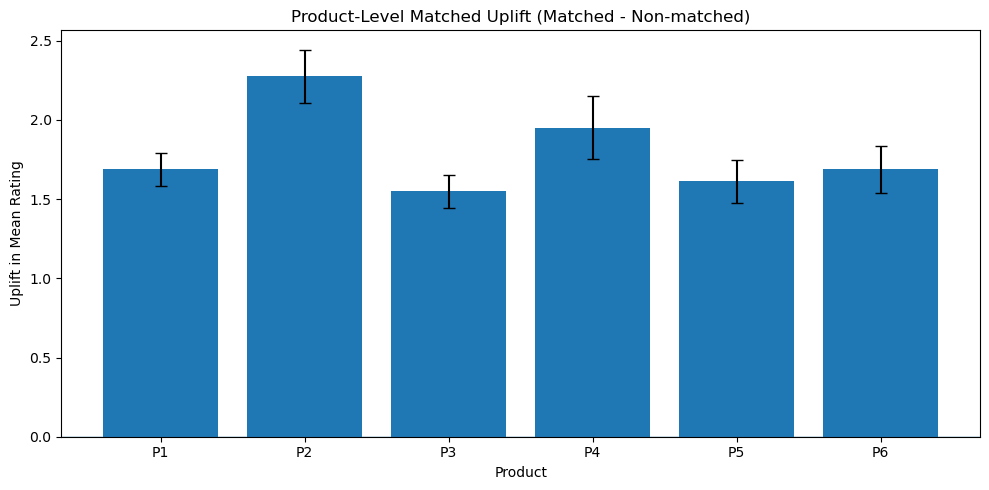

Saved:
- c:\Users\alect\OneDrive\Masters\031_Modeling_Communication_and_Abstraction_Part_I\Final project\AI_personality_persuasion-1\Stimulus_Builder\stimuli_out_analysed\ratings_analysis_pipeline\figures\06_product_level_matched_uplift.png
- c:\Users\alect\OneDrive\Masters\031_Modeling_Communication_and_Abstraction_Part_I\Final project\AI_personality_persuasion-1\Stimulus_Builder\stimuli_out_analysed\ratings_analysis_pipeline_notebook\figures\06_product_level_matched_uplift.png


In [10]:
# Descriptive uplift uncertainty uses independent-groups approximation:
# SE(uplift) ~= sqrt(SE_matched^2 + SE_nonmatched^2)
uplift_plot_df = product_level_matched_uplift.copy()
uplift_plot_df["se_uplift"] = np.sqrt(
    uplift_plot_df["se_matched"].fillna(0.0) ** 2 + uplift_plot_df["se_nonmatched"].fillna(0.0) ** 2
)

x = np.arange(len(uplift_plot_df))
plt.figure(figsize=(10, 5))
plt.bar(
    x,
    uplift_plot_df["uplift_matched_minus_nonmatched"],
    yerr=uplift_plot_df["se_uplift"],
    capsize=4,
)
plt.axhline(0, linewidth=1)
plt.xticks(x, uplift_plot_df["product_id"], rotation=0)
plt.title("Product-Level Matched Uplift (Matched - Non-matched)")
plt.xlabel("Product")
plt.ylabel("Uplift in Mean Rating")
plt.tight_layout()

for target_dir in [CANONICAL_OUT_DIR, OUT_DIR]:
    fig_dir = target_dir / "figures"
    fig_dir.mkdir(parents=True, exist_ok=True)
    plt.savefig(fig_dir / "06_product_level_matched_uplift.png", dpi=300)

plt.show()
plt.close()

print("Saved:")
print("-", CANONICAL_OUT_DIR / "figures" / "06_product_level_matched_uplift.png")
print("-", OUT_DIR / "figures" / "06_product_level_matched_uplift.png")


This uplift figure checks whether matching effects appear broadly across products, instead of being driven by one or two materials.


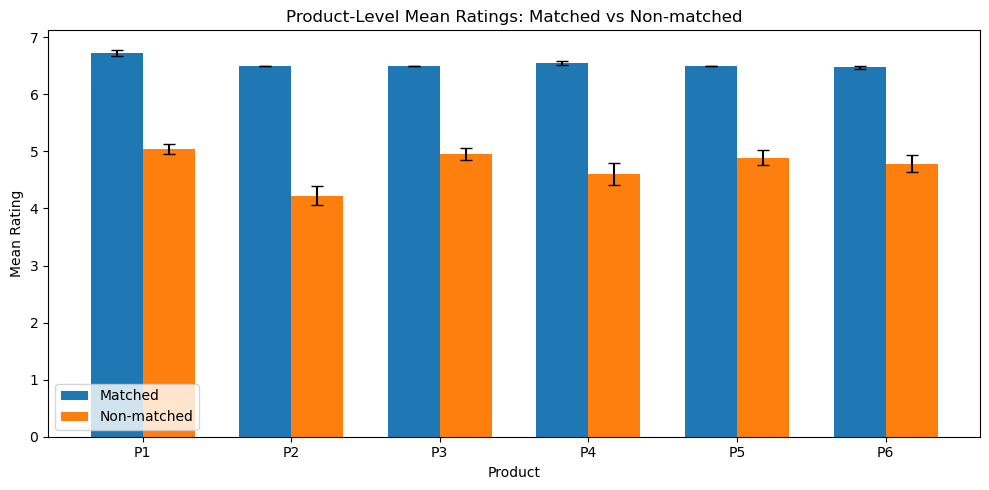

Saved:
- c:\Users\alect\OneDrive\Masters\031_Modeling_Communication_and_Abstraction_Part_I\Final project\AI_personality_persuasion-1\Stimulus_Builder\stimuli_out_analysed\ratings_analysis_pipeline\figures\07_product_level_matched_vs_nonmatched.png
- c:\Users\alect\OneDrive\Masters\031_Modeling_Communication_and_Abstraction_Part_I\Final project\AI_personality_persuasion-1\Stimulus_Builder\stimuli_out_analysed\ratings_analysis_pipeline_notebook\figures\07_product_level_matched_vs_nonmatched.png


In [11]:
means_df = product_level_matched_uplift.copy().sort_values("product_id").reset_index(drop=True)
x = np.arange(len(means_df))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(
    x - width / 2,
    means_df["mean_matched"],
    width=width,
    yerr=means_df["se_matched"],
    capsize=4,
    label="Matched",
)
plt.bar(
    x + width / 2,
    means_df["mean_nonmatched"],
    width=width,
    yerr=means_df["se_nonmatched"],
    capsize=4,
    label="Non-matched",
)
plt.xticks(x, means_df["product_id"], rotation=0)
plt.title("Product-Level Mean Ratings: Matched vs Non-matched")
plt.xlabel("Product")
plt.ylabel("Mean Rating")
plt.legend()
plt.tight_layout()

for target_dir in [CANONICAL_OUT_DIR, OUT_DIR]:
    fig_dir = target_dir / "figures"
    fig_dir.mkdir(parents=True, exist_ok=True)
    plt.savefig(fig_dir / "07_product_level_matched_vs_nonmatched.png", dpi=300)

plt.show()
plt.close()

print("Saved:")
print("-", CANONICAL_OUT_DIR / "figures" / "07_product_level_matched_vs_nonmatched.png")
print("-", OUT_DIR / "figures" / "07_product_level_matched_vs_nonmatched.png")


This grouped-mean figure complements the uplift chart by showing absolute mean levels for matched and non-matched conditions per product, not only difference scores.


## 8. Regression Analysis

Core interpretation of terms:

- `is_matched` tests whether matched messages are rated higher overall.
- `C(persona_trait)` tests whether persona groups differ in overall rating level.
- `is_matched:C(persona_trait)` tests whether the match effect depends on persona type (the core theoretical test).


**Model Interpretation Guide**

- `is_matched`: estimated difference between matched and unmatched messages at the reference persona trait.
- `C(persona_trait)`: baseline mean difference between persona groups.
- `is_matched:C(persona_trait)`: difference-in-differences term; this is the core test of whether match effects vary by persona type.

**How To Read The Coefficient Table**

- `coef`: estimated effect size in rating points.
- `p_value`: evidence against no-effect for that term.
- `ci_low` / `ci_high`: plausible interval for the effect.

**Inference Note**

- Clustered standard errors by `persona_id` are used when repeated ratings per persona exist.
- This improves inference under within-person dependence without requiring unstable mixed models.


In [12]:
def build_regression_formula(df: pd.DataFrame) -> str:
    base_terms = [
        "is_matched",
        "C(persona_trait)",
        "is_matched:C(persona_trait)",
    ]

    optional_controls = []
    for col in ["product_id", "paraphrase_id", "model"]:
        if col in df.columns and df[col].nunique(dropna=True) > 1:
            optional_controls.append(f"C({col})")

    rhs = " + ".join(base_terms + optional_controls)
    return f"rating ~ {rhs}"


def fit_regression(df: pd.DataFrame):
    model_df = df.copy()
    formula = build_regression_formula(model_df)
    print("Formula:", formula)

    ols = smf.ols(formula=formula, data=model_df)

    # Repeated observations per persona: cluster robust SEs by persona_id.
    # If that structure does not exist, fall back to HC3 robust SEs.
    if model_df["persona_id"].nunique() < len(model_df):
        result = ols.fit(cov_type="cluster", cov_kwds={"groups": model_df["persona_id"]})
        se_method = "clustered_by_persona_id"
    else:
        result = ols.fit(cov_type="HC3")
        se_method = "robust_HC3"

    coef_df = pd.DataFrame(
        {
            "term": result.params.index,
            "coef": result.params.values,
            "std_err": result.bse.values,
            "t_value": result.tvalues.values,
            "p_value": result.pvalues.values,
            "ci_low": result.conf_int().iloc[:, 0].values,
            "ci_high": result.conf_int().iloc[:, 1].values,
        }
    )
    return result, coef_df, se_method


reg_result, reg_coef_table, se_method = fit_regression(df_analysis)

print("SE method:", se_method)
print()
print("Coefficient table:")
print(reg_coef_table.to_string(index=False))
print()
print("Readable model summary:")
print(reg_result.summary())

regression_model_stats = pd.DataFrame(
    {
        "n_obs": [int(reg_result.nobs)],
        "r_squared": [float(getattr(reg_result, "rsquared", np.nan))],
        "adj_r_squared": [float(getattr(reg_result, "rsquared_adj", np.nan))],
        "f_stat": [float(getattr(reg_result, "fvalue", np.nan)) if getattr(reg_result, "fvalue", None) is not None else np.nan],
        "f_pvalue": [float(getattr(reg_result, "f_pvalue", np.nan))],
        "se_method": [se_method],
        "formula": [build_regression_formula(df_analysis)],
    }
)
regression_model_stats


Formula: rating ~ is_matched + C(persona_trait) + is_matched:C(persona_trait) + C(product_id)
SE method: clustered_by_persona_id

Coefficient table:
                                 term      coef  std_err    t_value       p_value    ci_low   ci_high
                            Intercept  4.700000 0.031713 148.205280  0.000000e+00  4.637844  4.762156
           C(persona_trait)[T.O_HIGH]  0.604167 0.029227  20.671788  6.217016e-95  0.546884  0.661450
                  C(product_id)[T.P2] -0.616667 0.024760 -24.905366 6.508097e-137 -0.665196 -0.568137
                  C(product_id)[T.P3] -0.133333 0.060650  -2.198394  2.792103e-02 -0.252206 -0.014461
                  C(product_id)[T.P4] -0.350000 0.053161  -6.583723  4.588127e-11 -0.454194 -0.245806
                  C(product_id)[T.P5] -0.175000 0.055332  -3.162718  1.563036e-03 -0.283449 -0.066551
                  C(product_id)[T.P6] -0.250000 0.088602  -2.821595  4.778542e-03 -0.423657 -0.076343
                           is_match

,n_obs,r_squared,adj_r_squared,f_stat,f_pvalue,se_method,formula
0,360,0.618899,0.610213,5239.130973,4.306091e-30,clustered_by_persona_id,rating ~ is_matched + C(persona_trait) + is_ma...


## 9. Manipulation Checks


**Purpose Of Manipulation Checks**

- Confirms that delivered `variant` labels align with expected design assignment given `persona_trait` and `condition_label`.

**How To Read Output**

- `proportion_correct` near `1.0` indicates clean implementation of assignment logic.
- Lower values suggest pipeline or merge issues that should be fixed before strong interpretation.


In [13]:
def expected_variant_from_persona_and_condition(persona_trait: str, condition_label: str) -> str:
    persona_trait = str(persona_trait)
    condition_label = str(condition_label)

    if persona_trait == "E_HIGH":
        return {
            "TARGETED": "E_PLUS",
            "NON_TARGETED": "O_PLUS",
            "GENERIC": "GENERIC",
        }.get(condition_label, "UNKNOWN")

    if persona_trait == "O_HIGH":
        return {
            "TARGETED": "O_PLUS",
            "NON_TARGETED": "E_PLUS",
            "GENERIC": "GENERIC",
        }.get(condition_label, "UNKNOWN")

    return "UNKNOWN"


def manipulation_checks(df: pd.DataFrame) -> dict[str, pd.DataFrame]:
    checks: dict[str, pd.DataFrame] = {}

    if "condition_label" in df.columns:
        tmp = df.copy()
        tmp["expected_variant"] = tmp.apply(
            lambda r: expected_variant_from_persona_and_condition(r["persona_trait"], r["condition_label"]),
            axis=1,
        )
        tmp["variant_matches_design"] = (tmp["variant"] == tmp["expected_variant"]).astype(int)

        checks["manipulation_check_design_integrity"] = (
            tmp.groupby(["persona_trait", "condition_label"], dropna=False)
            .agg(
                n=("variant_matches_design", "size"),
                proportion_correct=("variant_matches_design", "mean"),
            )
            .reset_index()
            .sort_values(["persona_trait", "condition_label"])
        )

        checks["manipulation_check_variant_x_trait_counts"] = (
            tmp.groupby(["persona_trait", "variant"], dropna=False)
            .size()
            .reset_index(name="n")
            .sort_values(["persona_trait", "variant"])
        )
    else:
        checks["manipulation_check_design_integrity"] = pd.DataFrame(
            {"note": ["condition_label missing; design integrity check skipped"]}
        )

    return checks


manip_tables = manipulation_checks(df_analysis)
for name, table in manip_tables.items():
    print()
    print(name)
    display(table)



manipulation_check_design_integrity


,persona_trait,condition_label,n,proportion_correct
0,E_HIGH,GENERIC,60,1.0
1,E_HIGH,NON_TARGETED,60,1.0
2,E_HIGH,TARGETED,60,1.0
3,O_HIGH,GENERIC,60,1.0
4,O_HIGH,NON_TARGETED,60,1.0
5,O_HIGH,TARGETED,60,1.0



manipulation_check_variant_x_trait_counts


,persona_trait,variant,n
0,E_HIGH,E_PLUS,60
1,E_HIGH,GENERIC,60
2,E_HIGH,O_PLUS,60
3,O_HIGH,E_PLUS,60
4,O_HIGH,GENERIC,60
5,O_HIGH,O_PLUS,60


## 10. Motivation Text Analysis (Exploratory)


**What This Exploratory Step Adds**

- Provides qualitative context for why messages may have been rated as more or less persuasive.
- Summarizes frequent words and short phrases overall and by matched status.

**Interpretation Caution**

- This is descriptive, not causal.
- Frequent terms can suggest themes (for example social resonance or novelty language) but do not replace the regression tests.


In [14]:
def tokenize_text(text: str) -> list[str]:
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = [t for t in text.split() if len(t) >= 3 and t not in STOPWORDS]
    return tokens


def motivation_text_analysis(df: pd.DataFrame, top_n: int = 25) -> dict[str, pd.DataFrame]:
    outputs: dict[str, pd.DataFrame] = {}

    if "motivation" not in df.columns:
        outputs["motivation_note"] = pd.DataFrame(
            {"note": ["No motivation column found; text analysis skipped."]}
        )
        return outputs

    tmp = df.copy()
    tmp["motivation"] = tmp["motivation"].fillna("").astype(str).str.strip()
    tmp = tmp[tmp["motivation"] != ""].copy()

    if tmp.empty:
        outputs["motivation_note"] = pd.DataFrame(
            {"note": ["Motivation column present, but all entries are empty."]}
        )
        return outputs

    all_tokens: list[str] = []
    all_bigrams: list[str] = []

    for txt in tmp["motivation"]:
        tokens = tokenize_text(txt)
        all_tokens.extend(tokens)
        all_bigrams.extend([f"{tokens[i]} {tokens[i + 1]}" for i in range(len(tokens) - 1)])

    outputs["motivation_top_words_overall"] = pd.DataFrame(
        Counter(all_tokens).most_common(top_n), columns=["word", "count"]
    )
    outputs["motivation_top_bigrams_overall"] = pd.DataFrame(
        Counter(all_bigrams).most_common(top_n), columns=["bigram", "count"]
    )

    grouped_rows = []
    for matched_value, group in tmp.groupby("is_matched"):
        tokens: list[str] = []
        for txt in group["motivation"]:
            tokens.extend(tokenize_text(txt))
        for word, count in Counter(tokens).most_common(15):
            grouped_rows.append(
                {
                    "is_matched": int(matched_value),
                    "word": word,
                    "count": count,
                }
            )
    outputs["motivation_top_words_by_matched"] = pd.DataFrame(grouped_rows)

    return outputs


motivation_tables = motivation_text_analysis(df_analysis)
for name, table in motivation_tables.items():
    print()
    print(name)
    display(table.head(25))



motivation_top_words_overall


,word,count
0,social,170
1,imaginative,167
2,energy,161
3,preference,150
4,lacks,144
5,framing,139
6,lively,137
7,but,128
8,would,111
9,make,101



motivation_top_bigrams_overall


,bigram,count
0,but lacks,105
1,social energy,87
2,imaginative framing,82
3,lively social,73
4,preference novelty,66
5,functional but,64
6,lacks lively,63
7,clear functional,60
8,would make,57
9,energy confident,51



motivation_top_words_by_matched


,is_matched,word,count
0,0,lacks,144
1,0,but,128
2,0,social,116
3,0,energy,115
4,0,would,111
5,0,imaginative,107
6,0,lively,85
7,0,feels,82
8,0,preference,79
9,0,engage,72


## 11. Export Tables


**What Gets Exported**

- `analysis_rows_standardized.csv`: cleaned analysis-ready row-level dataset.
- `descriptive_table_for_paper.csv`: key descriptive summary table.
- `regression_results_table.csv` and `regression_model_stats.csv`: inferential outputs for reporting.
- `manipulation_check_table_for_paper.csv`: design integrity summary.

**Reporting Tip**

- Use descriptives for context and sample transparency.
- Use regression tables for hypothesis claims (especially the interaction term).


In [15]:
def export_tables(
    out_dir: Path,
    df_final: pd.DataFrame,
    descriptive: dict[str, pd.DataFrame],
    coef_table: pd.DataFrame,
    manipulation: dict[str, pd.DataFrame],
    motivation_tables: dict[str, pd.DataFrame],
) -> None:
    out_dir.mkdir(parents=True, exist_ok=True)

    df_final.to_csv(out_dir / "analysis_rows_standardized.csv", index=False)

    for name, table in descriptive.items():
        table.to_csv(out_dir / f"{name}.csv", index=False)

    coef_table.to_csv(out_dir / "regression_results_table.csv", index=False)

    for name, table in manipulation.items():
        table.to_csv(out_dir / f"{name}.csv", index=False)

    for name, table in motivation_tables.items():
        table.to_csv(out_dir / f"{name}.csv", index=False)


export_descriptive = dict(descriptive)
export_descriptive["descriptive_table_for_paper"] = (
    df_analysis.groupby(["persona_trait", "is_matched"], dropna=False)["rating"]
    .agg(["count", "mean", "std"])
    .reset_index()
    .rename(columns={"count": "n", "mean": "rating_mean", "std": "rating_sd"})
)

export_manip = dict(manip_tables)
export_manip["manipulation_check_table_for_paper"] = export_manip["manipulation_check_design_integrity"]

export_tables(
    out_dir=OUT_DIR,
    df_final=df_analysis,
    descriptive=export_descriptive,
    coef_table=reg_coef_table,
    manipulation=export_manip,
    motivation_tables=motivation_tables,
)

regression_model_stats.to_csv(OUT_DIR / "regression_model_stats.csv", index=False)

print("Analysis export complete.")
print("Output directory:", OUT_DIR)
print()
print("Key files:")
print("-", OUT_DIR / "analysis_rows_standardized.csv")
print("-", OUT_DIR / "descriptive_table_for_paper.csv")
print("-", OUT_DIR / "regression_results_table.csv")
print("-", OUT_DIR / "regression_model_stats.csv")
print("-", OUT_DIR / "manipulation_check_table_for_paper.csv")


# Also persist product-level matched uplift if computed above.
if "product_level_matched_uplift" in globals():
    for target_dir in [CANONICAL_OUT_DIR, OUT_DIR]:
        target_dir.mkdir(parents=True, exist_ok=True)
        product_level_matched_uplift.to_csv(target_dir / "product_level_matched_uplift.csv", index=False)


Analysis export complete.
Output directory: c:\Users\alect\OneDrive\Masters\031_Modeling_Communication_and_Abstraction_Part_I\Final project\AI_personality_persuasion-1\Stimulus_Builder\stimuli_out_analysed\ratings_analysis_pipeline_notebook

Key files:
- c:\Users\alect\OneDrive\Masters\031_Modeling_Communication_and_Abstraction_Part_I\Final project\AI_personality_persuasion-1\Stimulus_Builder\stimuli_out_analysed\ratings_analysis_pipeline_notebook\analysis_rows_standardized.csv
- c:\Users\alect\OneDrive\Masters\031_Modeling_Communication_and_Abstraction_Part_I\Final project\AI_personality_persuasion-1\Stimulus_Builder\stimuli_out_analysed\ratings_analysis_pipeline_notebook\descriptive_table_for_paper.csv
- c:\Users\alect\OneDrive\Masters\031_Modeling_Communication_and_Abstraction_Part_I\Final project\AI_personality_persuasion-1\Stimulus_Builder\stimuli_out_analysed\ratings_analysis_pipeline_notebook\regression_results_table.csv
- c:\Users\alect\OneDrive\Masters\031_Modeling_Communicati